In [1]:
%load_ext autoreload
%autoreload 2


In [3]:
import scanpy as sc
import treedata as td
import pycea as py
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import pandas as pd

# Import utility functions made by Katie
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, '/project/imoskowitz/yubin/SmoNull_NMPs_mesoderm_biased_analysis')

from src.I_preprocessing.plot_preprocessing import plot_UMAP_custom

from lineage_utilities.tree_functions import *

In [29]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/"
output_path_plot = base_path+plot_dir+"/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/"
adata_fname = "Processed_data/E8_5.h5td"

In [23]:
adata = td.read_h5td(output_path_data+"Processed_data/E8_5.h5td")


In [24]:
adata.obs['cardiac_labels'].unique()

[NaN, 'pSHF', 'aSHF', 'Differentiating CM', 'CMs', 'JCF']
Categories (5, object): ['CMs', 'Differentiating CM', 'JCF', 'aSHF', 'pSHF']

In [25]:
adata.X = adata.layers["raw_counts"]

In [26]:
adata.obs['cardiac_labels'] = adata.obs['cardiac_labels'].astype('category')
adata.obs['tree'] = adata.obs['tree'].astype('category')
adata.obs['germ_layer'] = adata.obs['germ_layer'].astype('category')

In [10]:
tree_sizes = adata.obs['tree'].value_counts().sort_values(ascending=False)
print(tree_sizes.head(10))

# flag trees likely to be memory-heavy (dense O(n^2) LCA matrix)
LARGE_TREE_THRESHOLD = 2000  # adjust based on what crashed before
large_trees = tree_sizes[tree_sizes > LARGE_TREE_THRESHOLD].index.tolist()
print("Large trees (may need special handling):", large_trees)

tree
E8.5-R3-C1    19886
E8.5-R2-C1    15318
E8.5-R2-C2    12352
E8.5-R1-C1     6192
E8.5-R3-C2     4202
E8.5-R1-C3     2955
E8.5-R1-C2     2256
E8.5-R3-C3      664
E8.5-R1-C4      429
Name: count, dtype: int64
Large trees (may need special handling): ['E8.5-R3-C1', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.5-R1-C1', 'E8.5-R3-C2', 'E8.5-R1-C3', 'E8.5-R1-C2']


#### Pick a subset of cells that you want to plot

In [11]:
# E8.5 with Colgan Auto Annotation
# Cardiac_cell_types = {"Juxtacardiac field" : "Juxtacardiac field",
#                         "First heart field": "First heart field",
#                         "Second heart field": "Second heart field",
#                         "Anterior mesoderm": "anterior second heart field" 
#                       }

#### Debug memory problem

In [ ]:
import resource
def print_mem(label):
    print(f"{label}: {resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6:.2f} GB (peak RSS)")
    
clone_tdata = adata[adata.obs["tree"] == "E8.5-R3-C1"].copy()
print_mem("after subset")

# same preprocessing plot_tree_custom does before compute_lca_depth_points
add_obs_to_tree(clone_tdata, keys=["cardiac_labels", "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys="cardiac_labels", tree="E8.5-R3-C1", method="mode")
flag_mixed_nodes(clone_tdata, "E8.5-R3-C1", cell_type_key="cardiac_labels")
add_node_attrs_to_edges(clone_tdata, keys=["cardiac_labels", "germ_layer"])
print_mem('after preprocessing')

points, depth_count, leaf_order, valid_types = compute_lca_depth_points(
    clone_tdata, "E8.5-R3-C1", color="cardiac_labels", n_leaf=5, n_jobs=4
)
print_mem("after LCA computation")  # if it dies before this prints, it's the matrix

# only then try plotting
result = plot_tree_custom(clone_tdata, "E8.5-R3-C1", color="cardiac_labels", output_path_plot=output_path_plot)
print("plotting done")

In [ ]:
import gc

failed_trees = []

output_csv = output_path_plot + "depth_points_all_trees.csv"
csv_path = Path(output_csv)
if csv_path.exists():
    csv_path.unlink()  # start fresh; remove if you want to append across runs

for clone_key in adata.obs['tree'].unique():
    if pd.isna(clone_key) or clone_key == 'nan': # To catch cells that do not have a tree
        continue

    n_cells = tree_sizes.get(clone_key, 0)
    print(f"starting {clone_key} ({n_cells} cells)")
    
    try: 
        clone_tdata = adata[adata.obs["tree"] == clone_key].copy()

        # plotting + LCA computation happen once, together
        result = plot_tree_custom(clone_tdata, clone_key, color="cardiac_labels", output_path_plot=output_path_plot)

        points = result["points"]
        leaf_order = result["leaf_order"]

        rows = [{"tree": clone_key, "cell_type": ct, "depth": d, "pos": p, "n_leaves": len(leaf_order)}
                for d, p, ct in points]
        df_chunk = pd.DataFrame(rows)
        df_chunk.to_csv(output_csv, mode='a', header=not csv_path.exists(), index=False)
        del clone_tdata, result, points
    except MemoryError as e:
        print(f"MEMORY ERROR on {clone_key}, skipping: {e}")
        failed_trees.append(clone_key)
    except Exception as e:
        print(f"ERROR on {clone_key}, skipping: {e}")
        failed_trees.append(clone_key)
    finally:
        gc.collect()

    print(f"complete {clone_key}")

plt.close('all')  # belt-and-suspenders in case anything else left a figure open
print("Failed trees:", failed_trees)

#### Redo this plot to show more information regarding cell count per clone, proportion of cells that are cardiac, and cell count of every cardiac type

In [27]:
ct = pd.crosstab(adata.obs['tree'], adata.obs['cardiac_labels'], normalize='index') * 100
ct.round(1)

cardiac_labels,CMs,Differentiating CM,JCF,aSHF,pSHF
tree,,,,,
E8.5-R1-C1,27.1,14.8,4.5,24.2,29.5
E8.5-R1-C2,23.5,18.2,10.3,22.4,25.6
E8.5-R1-C3,38.4,15.1,8.1,15.8,22.5
E8.5-R1-C4,47.8,0.0,0.0,52.2,0.0
E8.5-R2-C1,29.7,17.7,7.7,19.4,25.5
E8.5-R2-C2,30.6,16.5,15.4,20.1,17.4
E8.5-R3-C1,27.5,17.0,16.7,22.7,16.1
E8.5-R3-C2,26.8,19.3,8.5,21.0,24.4
E8.5-R3-C3,19.6,16.1,12.5,26.8,25.0


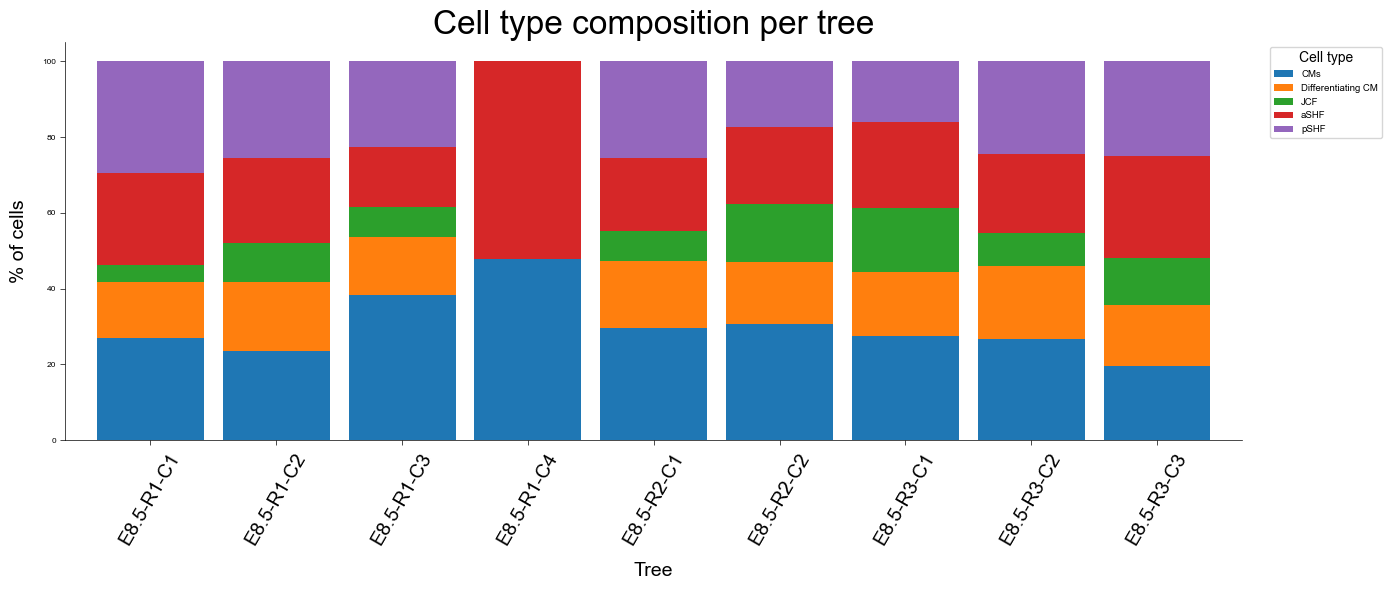

In [30]:
palette = get_color_palette(adata, color_key='cardiac_labels')
colors = [palette.get(ct, "gray") for ct in ct.columns]

ax = ct.plot(kind='bar', stacked=True, figsize=(14, 6), color=colors, width=0.85)
ax.set_ylabel("% of cells", size = 14)
ax.set_xlabel("Tree", size = 14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='center', fontsize=14)
ax.set_title("Cell type composition per tree", size = 24)
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(output_path_plot + "cardiac_celltype_composition_per_tree.png", bbox_inches='tight')

In [ ]:
clone_key = "E8.5-R2-C1"

In [27]:
clone_key = "E8.5-R2-C1"

#### Exploring the linkage of celltype and time

In [ ]:
def compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels', min_cells_per_tree=1):
    """
    Computes celltype-celltype fate coupling: correlation of cell type
    abundance across clones (trees). Positive correlation = types tend to
    co-occur in the same clone (likely share a recent progenitor).

    Returns
    -------
    coupling : DataFrame, celltype x celltype correlation matrix
    counts   : DataFrame, tree x celltype raw counts (for inspection)
    """
    counts = pd.crosstab(adata.obs[tree_key], adata.obs[celltype_key])
    counts = counts[counts.sum(axis=1) >= min_cells_per_tree]
    coupling = counts.corr()
    return coupling, counts


def plot_fate_coupling(coupling, output_path_plot=None, fname="fate_coupling.svg"):
    g = sns.clustermap(coupling, cmap="vlag", center=0, annot=True, fmt=".2f", figsize=(8, 8))
    g.figure.suptitle("Fate coupling across clones", y=1.02)
    if output_path_plot is not None:
        g.savefig(output_path_plot + fname, bbox_inches='tight')
        plt.close(g.fig)
    else:
        plt.show()
    return g

In [30]:
coupling, counts = compute_fate_coupling(adata, tree_key='tree', celltype_key='cardiac_labels')
plot_fate_coupling(coupling, output_path_plot=output_path_plot)

In [ ]:
import gc
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path

def analyze_tree(clone_tdata, clone_key, color, n_permutations=500, random_state=0):
    """
    Single-pass per-tree analysis: runs shared preprocessing once, then
    computes leaf-depth records, polytomy/resolution stats, and a
    same-type-vs-different-type LCA permutation test — all reusing the
    same tree_distance/LCA matrix and depth annotation.

    Returns
    -------
    dict with keys: "leaf_depth_rows", "resolution_stats", "permutation_stats"
    """
    # --- shared preprocessing (once per tree) ---
    add_obs_to_tree(clone_tdata, keys=[color, "germ_layer"])
    py.pp.add_depth(clone_tdata)
    py.tl.tree_distance(clone_tdata, tree=clone_key, metric="lca", key_added="lca")

    tree_graph = clone_tdata.obst[clone_key]
    leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
    n = len(leaf_order)

    leaf_idx_map = {name: i for i, name in enumerate(clone_tdata.obs_names)}
    leaf_indices = np.array([leaf_idx_map[l] for l in leaf_order])

    cell_types = clone_tdata.obs.loc[leaf_order, color].astype(str).to_numpy()
    valid_mask_leaf = ~np.isin(cell_types, ["nan", "None", "", "<NA>"])

    # --- leaf depth table (question 1) ---
    depths = clone_tdata.obs.loc[leaf_order, "depth"].to_numpy()
    max_depth = depths.max() if len(depths) else 1.0
    leaf_depth_rows = [
        {"tree": clone_key, "cell_type": ct, "depth": d,
         "depth_norm": d / max_depth if max_depth > 0 else 0.0, "n_leaves": n}
        for leaf, d, ct, valid in zip(leaf_order, depths, cell_types, valid_mask_leaf) if valid
    ]

    # --- polytomy / resolution diagnostic (question 3) ---
    out_degrees = dict(tree_graph.out_degree())
    polytomy_nodes = {node: d for node, d in out_degrees.items() if d > 2}
    node_depths = nx.get_node_attributes(tree_graph, "depth")
    polytomy_depths = [node_depths[node] for node in polytomy_nodes if node in node_depths]
    n_internal = sum(1 for node, d in out_degrees.items() if d > 0)

    resolution_stats = {
        "tree": clone_key,
        "n_leaves": n,
        "n_polytomies": len(polytomy_nodes),
        "n_internal_nodes": n_internal,
        "polytomy_fraction": len(polytomy_nodes) / max(1, n_internal),
        "mean_polytomy_depth_norm": (
            float(np.mean(polytomy_depths) / max_depth) if polytomy_depths and max_depth > 0 else np.nan
        ),
    }

    # --- pairwise LCA + permutation test (question 2) ---
    lca_depths = clone_tdata.obsp["lca_distances"]
    is_sparse = hasattr(lca_depths, "toarray")
    if is_sparse:
        lca_depths = lca_depths.tocsr()

    sub = lca_depths[leaf_indices, :][:, leaf_indices]
    if is_sparse:
        sub = sub.toarray()

    tri_i, tri_j = np.triu_indices(n, k=1)
    pair_depths = sub[tri_i, tri_j]
    valid_pair = valid_mask_leaf[tri_i] & valid_mask_leaf[tri_j]

    same_type = cell_types[tri_i] == cell_types[tri_j]
    same_mean = pair_depths[same_type & valid_pair].mean() if (same_type & valid_pair).any() else np.nan
    diff_mean = pair_depths[~same_type & valid_pair].mean() if (~same_type & valid_pair).any() else np.nan
    observed_diff = same_mean - diff_mean

    rng = np.random.default_rng(random_state)
    null_diffs = np.empty(n_permutations)
    for p in range(n_permutations):
        shuffled = rng.permutation(cell_types)
        same_type_p = shuffled[tri_i] == shuffled[tri_j]
        valid_p = ~np.isin(shuffled[tri_i], ["nan", "None", "", "<NA>"]) & \
                  ~np.isin(shuffled[tri_j], ["nan", "None", "", "<NA>"])
        same_mean_p = pair_depths[same_type_p & valid_p].mean() if (same_type_p & valid_p).any() else np.nan
        diff_mean_p = pair_depths[~same_type_p & valid_p].mean() if (~same_type_p & valid_p).any() else np.nan
        null_diffs[p] = same_mean_p - diff_mean_p

    p_value = (np.nansum(null_diffs >= observed_diff) + 1) / (n_permutations + 1)

    permutation_stats = {
        "tree": clone_key,
        "same_type_mean_lca_depth": same_mean,
        "diff_type_mean_lca_depth": diff_mean,
        "observed_diff": observed_diff,
        "p_value": p_value,
    }

    # free the dense matrix explicitly before returning
    del sub, lca_depths

    return {
        "leaf_depth_rows": leaf_depth_rows,
        "resolution_stats": resolution_stats,
        "permutation_stats": permutation_stats,
    }


def run_full_tree_analysis(adata, tree_key='tree', celltype_key='cardiac_labels',
                             output_dir=None, n_permutations=500, excluded_trees=None):
    """
    Loops over every tree once, running all diagnostics, and writes three
    combined output tables incrementally. Trees in `excluded_trees` are
    skipped entirely (e.g. very large trees to handle separately later).
    """
    excluded_trees = excluded_trees or set()

    leaf_depth_csv = output_dir + "leaf_depth_all_trees.csv"
    resolution_csv = output_dir + "resolution_all_trees.csv"
    permutation_csv = output_dir + "permutation_all_trees.csv"

    for path in [leaf_depth_csv, resolution_csv, permutation_csv]:
        p = Path(path)
        if p.exists():
            p.unlink()

    tree_sizes = adata.obs[tree_key].value_counts()
    failed_trees = []
    skipped_trees = []

    for clone_key in adata.obs[tree_key].unique():
        if pd.isna(clone_key) or clone_key == 'nan':
            continue

        if clone_key in excluded_trees:
            print(f"skipping {clone_key} (excluded)")
            skipped_trees.append(clone_key)
            continue

        n_cells = tree_sizes.get(clone_key, 0)
        print(f"analyzing {clone_key} ({n_cells} cells)")

        try:
            clone_tdata = adata[adata.obs[tree_key] == clone_key].copy()
            result = analyze_tree(clone_tdata, clone_key, color=celltype_key,
                                   n_permutations=n_permutations)

            pd.DataFrame(result["leaf_depth_rows"]).to_csv(
                leaf_depth_csv, mode='a', header=not Path(leaf_depth_csv).exists(), index=False)
            pd.DataFrame([result["resolution_stats"]]).to_csv(
                resolution_csv, mode='a', header=not Path(resolution_csv).exists(), index=False)
            pd.DataFrame([result["permutation_stats"]]).to_csv(
                permutation_csv, mode='a', header=not Path(permutation_csv).exists(), index=False)

            del clone_tdata, result

        except Exception as e:
            print(f"ERROR on {clone_key}, skipping: {e}")
            failed_trees.append(clone_key)

        finally:
            gc.collect()

        print(f"complete {clone_key}")

    print("Skipped trees (excluded):", skipped_trees)
    print("Failed trees:", failed_trees)
    return {
        "leaf_depth_csv": leaf_depth_csv,
        "resolution_csv": resolution_csv,
        "permutation_csv": permutation_csv,
        "failed_trees": failed_trees,
        "skipped_trees": skipped_trees,
    }

In [39]:
EXCLUDED_TREES = {"E8.5-R3-C1", "E8.5-R2-C1", "E8.5-R2-C2"}
paths = run_full_tree_analysis(
    adata,
    tree_key='tree',
    celltype_key='cardiac_labels',
    output_dir=output_path_plot,
    n_permutations=500,
    excluded_trees=EXCLUDED_TREES
)

analyzing E8.5-R1-C1 (6192 cells)


KeyboardInterrupt: 